In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [8]:
df_eda = pd.read_csv('F:/traffic-analysis-biratnagar/data/processed_data.csv')
X = df_eda.drop(columns=['Severity'])
y = df_eda['Severity']

In [9]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("=== Split Sizes ===")
print(f"Train : {X_train.shape[0]} rows | High={y_train.sum()} Low={( y_train==0).sum()}")
print(f"Val   : {X_val.shape[0]} rows | High={y_val.sum()} Low={(y_val==0).sum()}")
print(f"Test  : {X_test.shape[0]} rows | High={y_test.sum()} Low={(y_test==0).sum()}")

=== Split Sizes ===
Train : 639 rows | High=50 Low=589
Val   : 137 rows | High=11 Low=126
Test  : 137 rows | High=10 Low=127


In [10]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',   # handles class imbalance
    random_state=42,
    n_jobs=-1
)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=(y_train == 0).sum() / y_train.sum(),  # handles imbalance
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

rf.fit(X_train, y_train)
xgb.fit(X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [11]:
def evaluate_model(model, X, y, model_name, split_name):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    f1     = f1_score(y, y_pred)
    roc    = roc_auc_score(y, y_prob)
    print(f"\n{'='*50}")
    print(f"{model_name} — {split_name}")
    print(f"{'='*50}")
    print(classification_report(y, y_pred, target_names=['Low', 'High']))
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc:.4f}")
    return f1, roc, y_pred, y_prob

In [12]:
# Validation scores
rf_val_f1,  rf_val_roc,  _, _ = evaluate_model(rf,  X_val, y_val, "Random Forest", "Validation")
xgb_val_f1, xgb_val_roc, _, _ = evaluate_model(xgb, X_val, y_val, "XGBoost",       "Validation")

# Test scores
rf_test_f1,  rf_test_roc,  rf_test_pred,  rf_test_prob  = evaluate_model(rf,  X_test, y_test, "Random Forest", "Test")
xgb_test_f1, xgb_test_roc, xgb_test_pred, xgb_test_prob = evaluate_model(xgb, X_test, y_test, "XGBoost",       "Test")


Random Forest — Validation
              precision    recall  f1-score   support

         Low       0.92      0.98      0.95       126
        High       0.00      0.00      0.00        11

    accuracy                           0.91       137
   macro avg       0.46      0.49      0.48       137
weighted avg       0.84      0.91      0.87       137

F1 Score : 0.0000
ROC-AUC  : 0.6544

XGBoost — Validation
              precision    recall  f1-score   support

         Low       0.93      0.89      0.91       126
        High       0.12      0.18      0.15        11

    accuracy                           0.83       137
   macro avg       0.53      0.54      0.53       137
weighted avg       0.86      0.83      0.85       137

F1 Score : 0.1481
ROC-AUC  : 0.5462

Random Forest — Test
              precision    recall  f1-score   support

         Low       0.93      0.98      0.95       127
        High       0.00      0.00      0.00        10

    accuracy                          

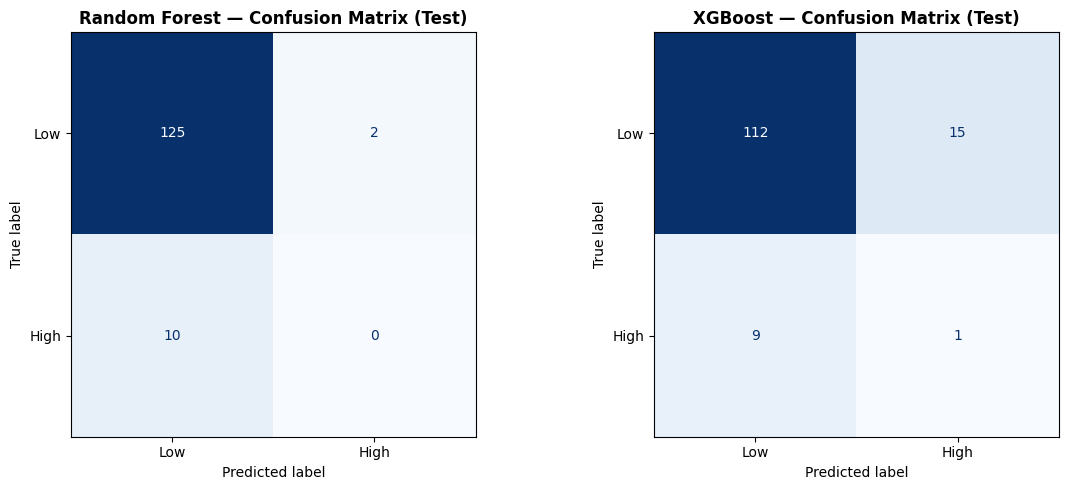

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, title in zip(axes,
                            [rf_test_pred, xgb_test_pred],
                            ['Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'High'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title} — Confusion Matrix (Test)', fontweight='bold')

plt.tight_layout()
plt.show()